In [2]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 124.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 120.4 MB/s eta 0:00:00


In [3]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

In [4]:
dev=qml.device("default.qubit",wires=5)


In [5]:
@qml.qnode(dev)
def quantum_circuit():
  for i in range(5):        # Applying Hadamard gates to wires(qubits)
    qml.Hadamard(wires=i)

  for i in range(5):
    qml.CNOT(wires=[i,(i+1)%5])

  qml.SWAP(wires=[0,4])

  qml.RX(np.pi/2, wires=2)

  return qml.state()


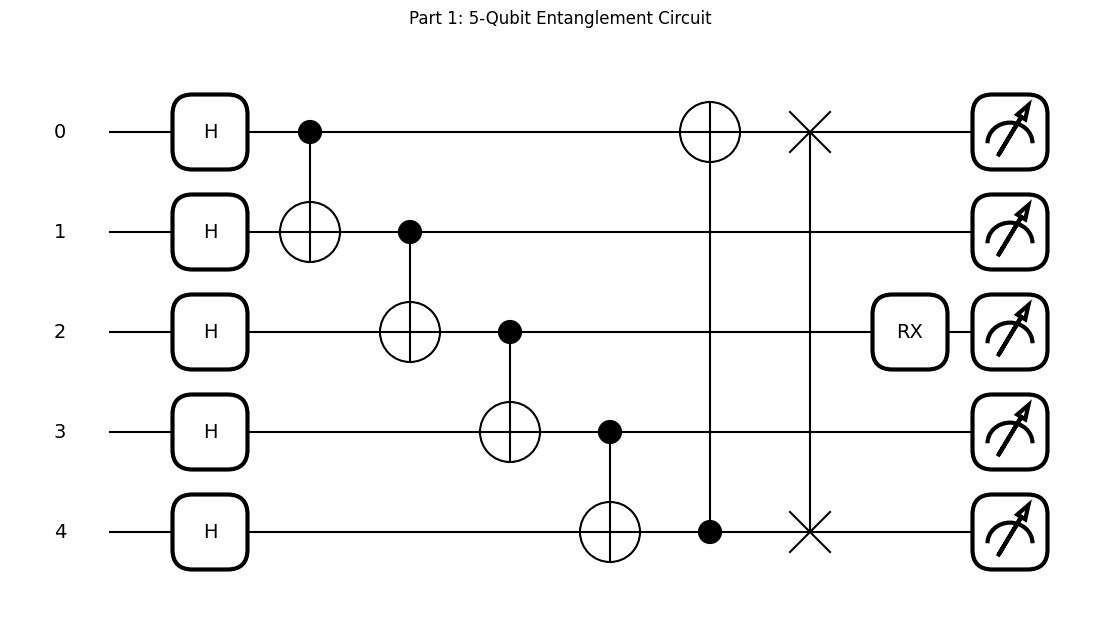

In [6]:
# Execute and Plot the circuit
fig, ax = qml.draw_mpl(quantum_circuit)()
plt.title("Part 1: 5-Qubit Entanglement Circuit")
plt.show()

=== RESULTS ===
Probability of measuring 0: 75.00%
Calculated Fidelity (Similarity) between State A and State B: 50.00%


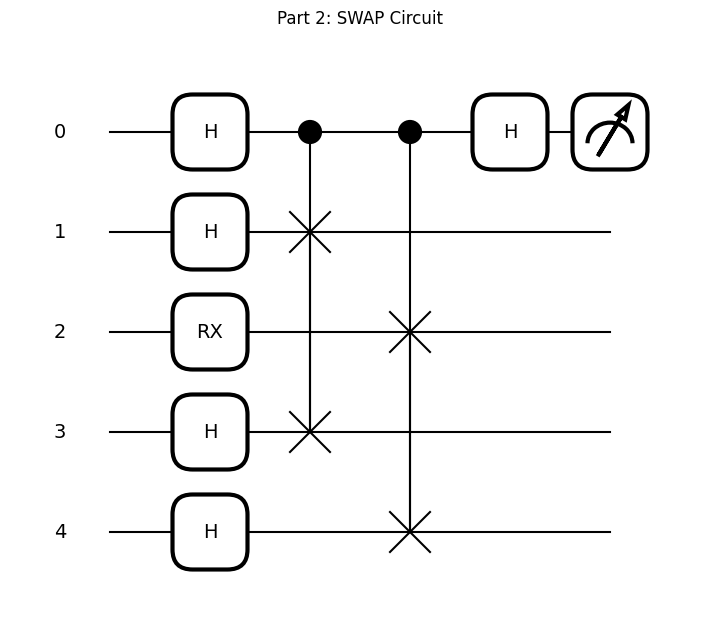

In [7]:
import pennylane as qml
import numpy as np

dev = qml.device("default.qubit", wires=5)

@qml.qnode(dev)
def swap_test_circuit():

    # State A: |q1 q2>
    qml.Hadamard(wires=1)
    qml.RX(np.pi / 3, wires=2)

    # State B: |q3 q4>
    qml.Hadamard(wires=3)
    qml.Hadamard(wires=4)

    # 1. Put the Ancilla (wire 0) in superposition
    qml.Hadamard(wires=0)

    # 2. Controlled-SWAP: Use Ancilla to swap q1 with q3
    qml.CSWAP(wires=[0, 1, 3])

    # 3. Controlled-SWAP: Use Ancilla to swap q2 with q4
    qml.CSWAP(wires=[0, 2, 4])

    # 4. Close the interference on the Ancilla
    qml.Hadamard(wires=0)

    return qml.probs(wires=0)


# Run the circuit and print the result
probabilities = swap_test_circuit()
prob_0 = probabilities[0]

print("=== RESULTS ===")
print(f"Probability of measuring 0: {prob_0 * 100:.2f}%")

# Probability of 0 = 0.5 + 0.5 * (Fidelity)
# Therefore, Fidelity = 2 * (Prob_0 - 0.5)
fidelity = 2 * (prob_0 - 0.5)
print(f"Calculated Fidelity (Similarity) between State A and State B: {fidelity * 100:.2f}%")

# Execute and Plot the circuit
fig, ax = qml.draw_mpl(swap_test_circuit)()
plt.title("Part 2: SWAP Circuit")
plt.show()